<a href="https://colab.research.google.com/github/mp371366/ML/blob/main/LAB10ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 10

## Trenowanie sieci

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Ustawienie urządzenia (GPU jeśli dostępne)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Pobranie i przygotowanie danych MNIST
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 2. Definicja modelu LeNet-5
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2), # 28x28 -> 28x28
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),     # 28x28 -> 14x14
            nn.Conv2d(6, 16, kernel_size=5),           # 14x14 -> 10x10
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2)      # 10x10 -> 5x5
        )
        self.classifier = nn.Sequential(
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# 3. Trening klasyfikatora (szybkie 3 epoki)
model = LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Trenowanie bazowego modelu klasyfikacji... Proszę czekać.")
model.train()
for epoch in range(30):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
print("Model gotowy do śnienia!")

Trenowanie bazowego modelu klasyfikacji... Proszę czekać.
Model gotowy do śnienia!


## Snienie

In [ ]:
def run_cnn_dream(model, lambda_l2=0.0, steps=200, lr=0.1):
    # Inicjalizacja: 10 losowych obrazów szumu (jeden dla każdej cyfry)
    # Wymiary: [Batch=10, Channels=1, Height=28, Width=28]
    input_images = torch.randn(10, 1, 28, 28, device=device, requires_grad=True)
    target_labels = torch.arange(10, device=device) # Cele: 0, 1, 2... 9

    optimizer = optim.Adam([input_images], lr=lr)
    criterion = nn.CrossEntropyLoss()

    confidence_history = []

    for step in range(steps):
        optimizer.zero_grad()

        outputs = model(input_images)
        loss_ce = criterion(outputs, target_labels)

        # Kara L2 na wartości pikseli
        loss_l2 = lambda_l2 * input_images.pow(2).mean()

        total_loss = loss_ce + loss_l2
        total_loss.backward()
        optimizer.step()

        # Zapisywanie pewności sieci (Softmax) dla wykresu
        with torch.no_grad():
            probs = torch.softmax(outputs, dim=1)
            target_probs = probs[torch.arange(10), target_labels].cpu().numpy()
            confidence_history.append(target_probs)

    return input_images.detach().cpu(), np.array(confidence_history)

# Przeprowadźmy eksperyment dla różnych lambda
lambdas = [0.0, 0.01, 0.1, 1.0, 10.0]
results = {}

for lmbd in lambdas:
    print(f"Optymalizacja dla lambda_l2 = {lmbd}...")
    imgs, confs = run_cnn_dream(model, lambda_l2=lmbd)
    results[lmbd] = (imgs, confs)

Optymalizacja dla lambda_l2 = 0.0...
Optymalizacja dla lambda_l2 = 0.01...
Optymalizacja dla lambda_l2 = 0.1...
Optymalizacja dla lambda_l2 = 1.0...
Optymalizacja dla lambda_l2 = 10.0...


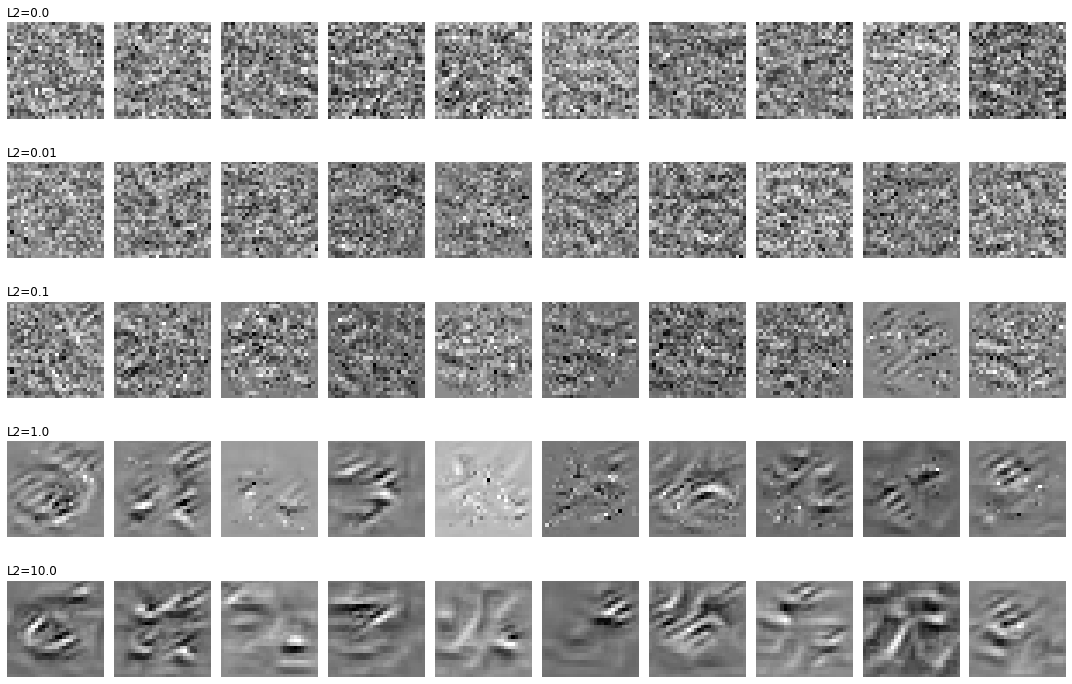

In [ ]:
fig, axes = plt.subplots(len(lambdas), 10, figsize=(15, 2 * len(lambdas)))
for i, lmbd in enumerate(lambdas):
    imgs, _ = results[lmbd]
    for j in range(10):
        ax = axes[i, j]
        # Mapujemy wartości do zakresu [0, 1] dla ładniejszego wyświetlania
        img = imgs[j].squeeze().numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if j == 0:
            ax.set_title(f"L2={lmbd}", loc='left')
plt.tight_layout()
plt.show()

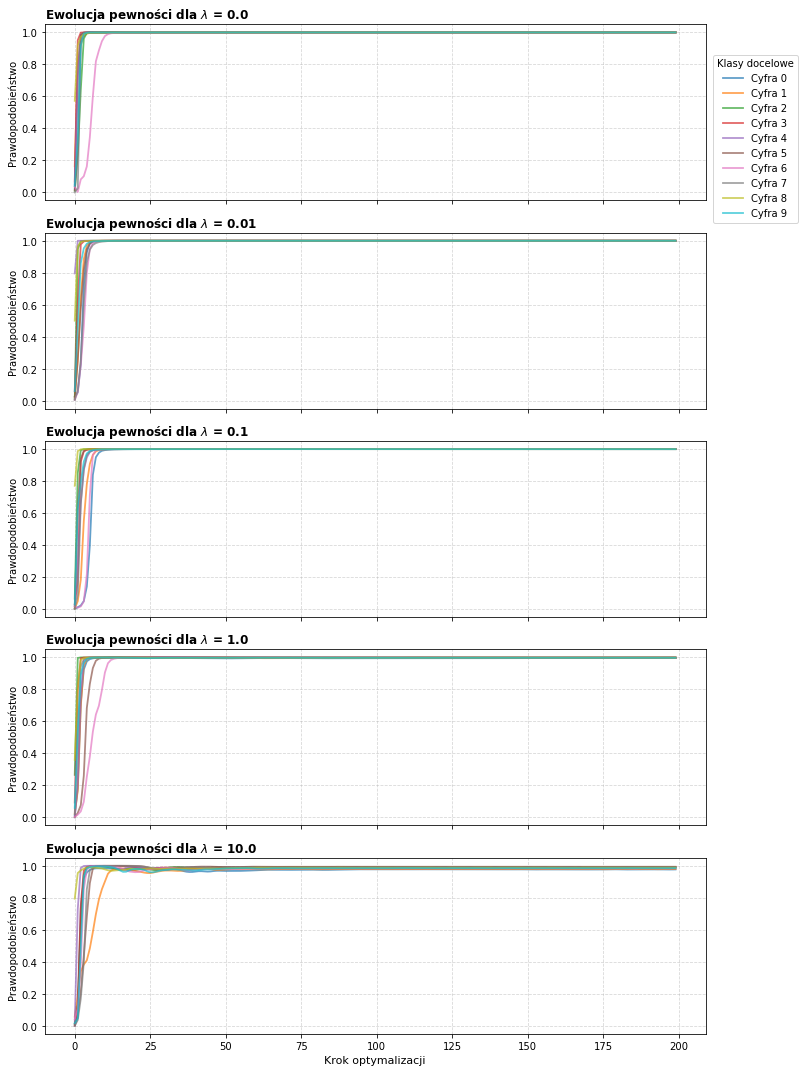

In [ ]:
# --- KOD RYSUJĄCY WYKRESY PEWNOŚCI DLA WSZYSTKICH LAMBDA ---

# Tworzymy siatkę wykresów liniowych: 1 wiersz na każdą lambdę
fig_plots, axes_plots = plt.subplots(len(lambdas), 1, figsize=(10, 3 * len(lambdas)), sharex=True)

# Na wypadek, gdyby na liście była tylko jedna lambda (żeby axes zawsze było iterowalne)
if len(lambdas) == 1:
    axes_plots = [axes_plots]

for i, lmbd in enumerate(lambdas):
    ax = axes_plots[i]
    _, conf_history = results[lmbd]  # Pobieramy historię pewności dla danej lambdy

    # conf_history ma kształt [kroki, 10 cyfr]
    steps_count = conf_history.shape[0]

    # Rysujemy linię dla każdej z 10 cyfr
    for digit in range(10):
        ax.plot(conf_history[:, digit], label=f"Cyfra {digit}" if i == 0 else "", alpha=0.7, linewidth=1.8)

    ax.set_title(f"Ewolucja pewności dla $\lambda$ = {lmbd}", fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel("Prawdopodobieństwo", fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle="--", alpha=0.5)

# Dodajemy etykietę osi X tylko na samym dole
axes_plots[-1].set_xlabel("Krok optymalizacji", fontsize=11)

# Dodajemy jedną wspólną legendę dla całego wykresu po prawej stronie
fig_plots.legend(loc="upper right", bbox_to_anchor=(1.12, 0.95), title="Klasy docelowe")

plt.tight_layout()
plt.show()

## Komentarz do zadania 1

Porównanie CNN Dreams z MLP. Czy obrazy z CNN są bardziej czytelne niż z MLP?
Zazwyczaj obrazy generowane przez CNN bez kary L2 ($\lambda=0$) przypominają abstrakcyjne, powtarzalne wzory (tekstury, krawędzie), podczas gdy MLP generuje bardziej chaotyczny, punktowy szum ("chmury" pikseli). Żadne z nich bez regularyzacji nie przypomina idealnej cyfry pisanej ludzką ręką.

Dlaczego tak się dzieje? (Inductive Biases / Architectural properties)
CNN posiada cechę niezmienniczości przesunięcia (translation invariance) oraz lokalności (filtry konwolucyjne patrzą na małe okna pikseli). Dlatego sieć szuka konkretnych cech (np. ukośna kreska, pętla) gdziekolwiek na obrazie. Zoptymalizowany obraz będzie więc pełen powielonych cech wykrywanych przez filtry na różnych warstwach.MLP nie ma pojęcia o przestrzennej strukturze obrazu – traktuje każdy piksel niezależnie. Optymalizuje więc konkretne, sztywne współrzędne pikseli.

Wpływ kary L2: Wyższa kara L2 tłumi ekstremalne wartości pikseli, zmuszając obraz do bycia "szarym" i bardziej stonowanym. Zapobiega to powstawaniu ostrych, nienaturalnych linii o wysokim kontraście.

## Zadanie 2

--- Start wielkiego ataku: Cyfra 2 zamieniana w klasy [0, 1, 3, 4, 5, 6, 7, 8, 9] ---

Generowanie ataków dla celu -> Cyfra 0

Generowanie ataków dla celu -> Cyfra 1

Generowanie ataków dla celu -> Cyfra 3

Generowanie ataków dla celu -> Cyfra 4

Generowanie ataków dla celu -> Cyfra 5

Generowanie ataków dla celu -> Cyfra 6

Generowanie ataków dla celu -> Cyfra 7

Generowanie ataków dla celu -> Cyfra 8

Generowanie ataków dla celu -> Cyfra 9

Wszystkie kombinacje optymalizacji zostały zakończone! Generowanie wizualizacji...


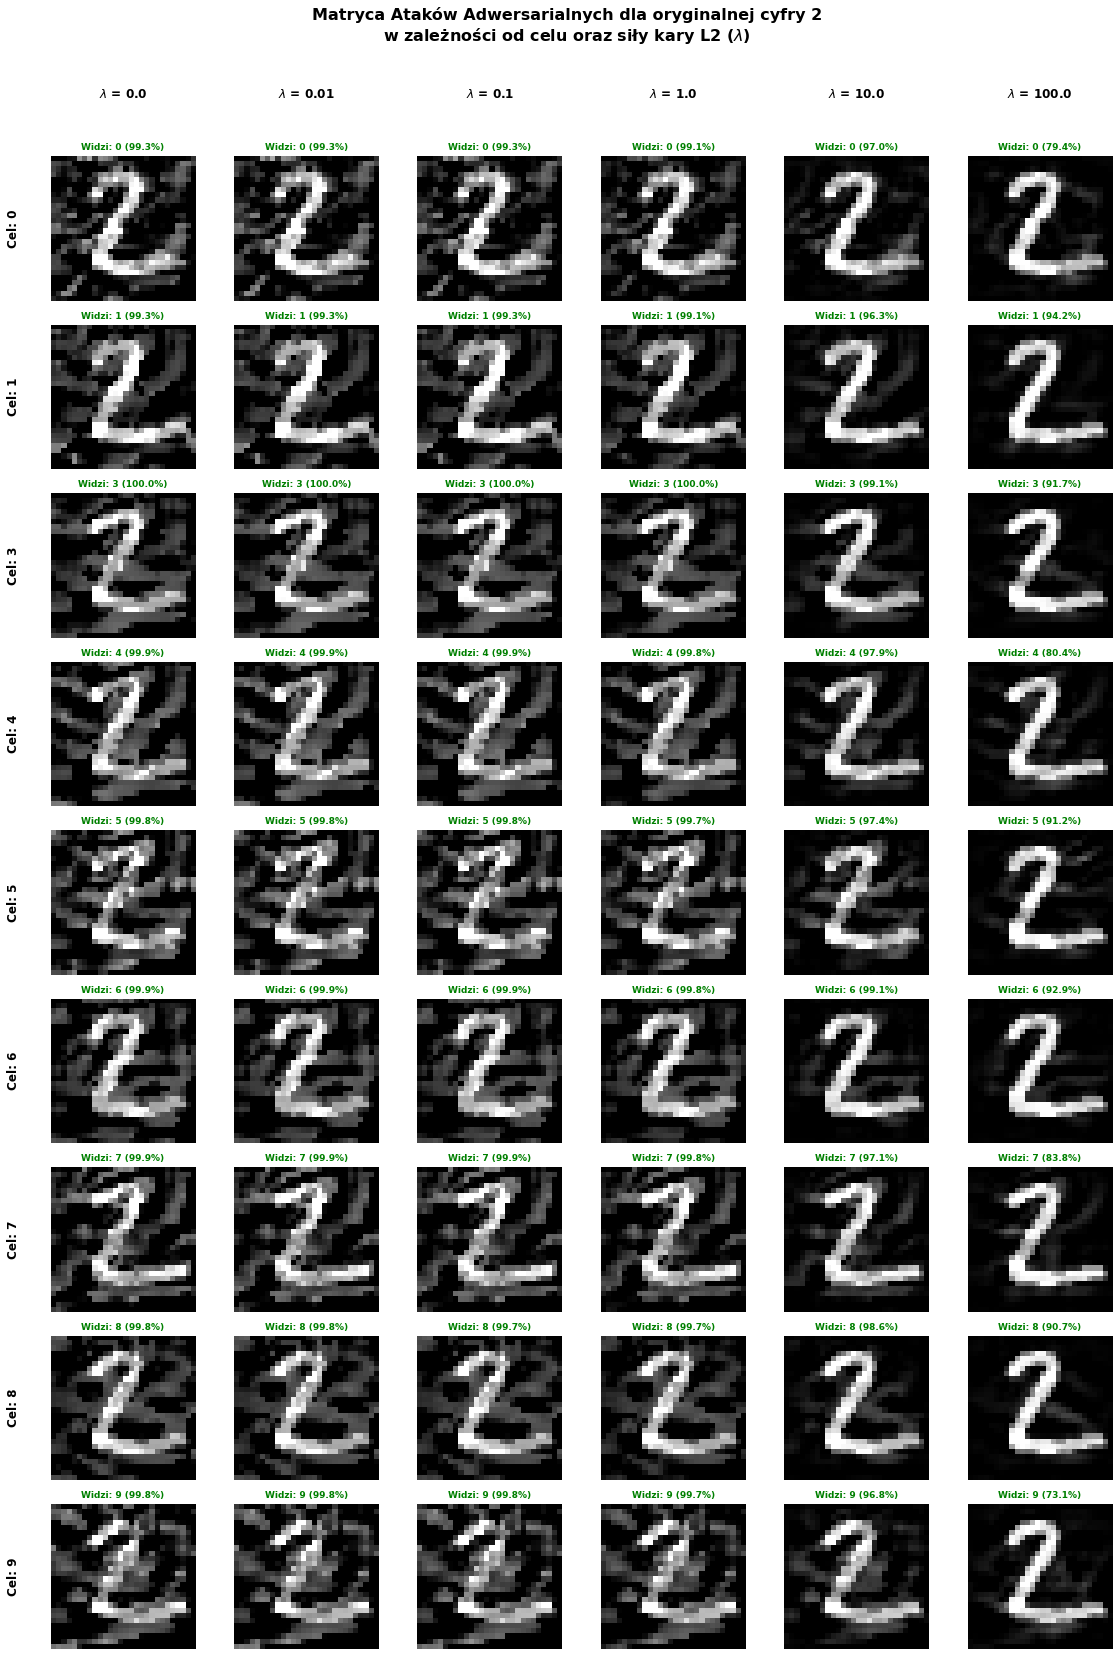

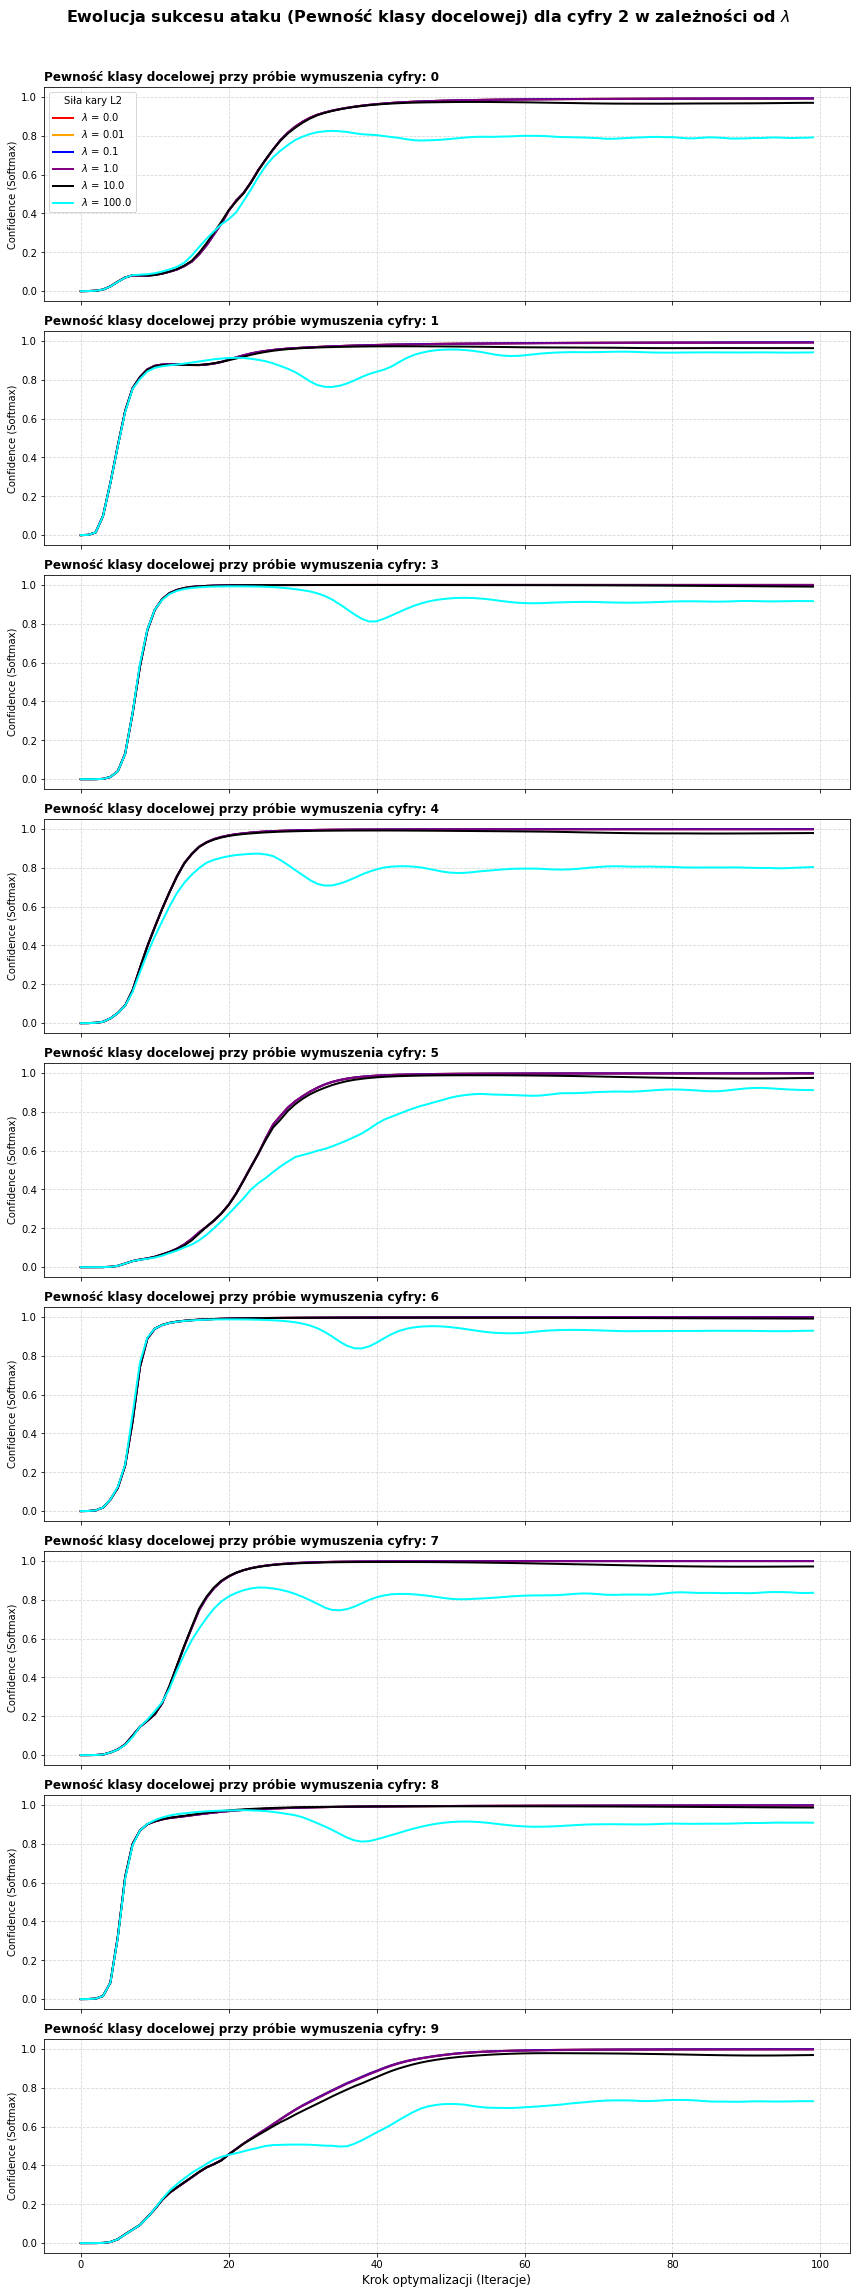

In [ ]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch

# 1. Pobranie zbioru testowego MNIST (jeśli potrzebne)
transform = transforms.Compose([transforms.ToTensor()])
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# 2. Wyciągnięcie po jednym czystym przykładzie dla każdej cyfry (0-9)
mnist_examples = {}
for img, label in test_loader:
    label_item = label.item()
    if label_item not in mnist_examples and len(mnist_examples) < 10:
        mnist_examples[label_item] = img.to(device)
    if len(mnist_examples) == 10:
        break

# --- URUCHOMIENIE DUŻEGO EKSPERYMENTU DLA WSZYSTKICH KLAS DOCELOWYCH ---

lambdas_to_test = [0.0, 0.01, 0.1, 1.0, 10.0, 100.0]
source_digit = 2
real_img = mnist_examples[source_digit]

# Lista cyfr docelowych (wszystkie od 0 do 9 z wykluczeniem 7)
target_digits = [d for d in range(10) if d != source_digit]

# Główny słownik na wyniki: struktura [target_digit][lambda]
full_experiment_results = {}

print(f"--- Start wielkiego ataku: Cyfra {source_digit} zamieniana w klasy {target_digits} ---")

for target_digit in target_digits:
    full_experiment_results[target_digit] = {}
    print(f"\nGenerowanie ataków dla celu -> Cyfra {target_digit}")

    for lmbd in lambdas_to_test:
        # Wywołanie TWOJEJ funkcji optymalizacyjnej
        delta, adv_img, true_hist, target_hist = create_adversarial_with_plots(
            model=model,
            real_image=real_img,
            true_label=source_digit,
            target_label=target_digit,
            lambda_l2=lmbd,
            steps=100,
            lr=0.02
        )

        # Ocena końcowa modelu
        with torch.no_grad():
            final_output = model(adv_img.to(device))
            pred_class = torch.argmax(final_output, dim=1).item()
            final_probs = torch.softmax(final_output, dim=1).squeeze().cpu().numpy()
            final_confidence = final_probs[pred_class]

        # Zapisujemy wszystko do struktury danych
        full_experiment_results[target_digit][lmbd] = {
            'adv_img': adv_img.squeeze().numpy(),
            'pred_class': pred_class,
            'confidence': final_confidence,
            'true_hist': true_hist,
            'target_hist': target_hist
        }

print("\nWszystkie kombinacje optymalizacji zostały zakończone! Generowanie wizualizacji...")


# --- WIZUALIZACJA 1: MATRYCA WYGENEROWANYCH OBRAZÓW (9 wierszy x 5 kolumn) ---

fig_imgs, axes_imgs = plt.subplots(len(target_digits), len(lambdas_to_test), figsize=(16, 2.5 * len(target_digits)))

for row_idx, target_digit in enumerate(target_digits):
    for col_idx, lmbd in enumerate(lambdas_to_test):

        res = full_experiment_results[target_digit][lmbd]
        ax = axes_imgs[row_idx, col_idx]

        ax.imshow(res['adv_img'], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')

        title_color = 'green' if res['pred_class'] == target_digit else 'red'
        ax.set_title(f"Widzi: {res['pred_class']} ({res['confidence']*100:.1f}%)",
                     color=title_color, fontsize=9, fontweight='bold')

        if row_idx == 0:
            ax.text(0.5, 1.4, f"$\lambda$ = {lmbd}", transform=ax.transAxes,
                    fontsize=12, fontweight='bold', ha='center')
        if col_idx == 0:
            ax.text(-0.3, 0.5, f"Cel: {target_digit}", transform=ax.transAxes,
                    fontsize=12, fontweight='bold', va='center', rotation=90)

plt.suptitle(f"Matryca Ataków Adwersarialnych dla oryginalnej cyfry {source_digit}\nw zależności od celu oraz siły kary L2 ($\lambda$)",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# --- WIZUALIZACJA 2: MATRYCA WYKRESÓW PEWNOŚCI (9 wierszy x 1 kolumna zbiorcza) ---
# Każdy wykres pokazuje linie ataku dla różnych lambd, żeby nie zaciemniać obrazu zbyt dużą liczbą osi

fig_plots, axes_plots = plt.subplots(len(target_digits), 1, figsize=(12, 3.5 * len(target_digits)), sharex=True)

# Definiujemy kolory dla poszczególnych lambd, aby łatwo je rozróżnić
colors = {0.0: 'red', 0.01: 'orange', 0.1: 'blue', 1.0: 'purple', 10.0: 'black', 100.0: 'cyan'}

for row_idx, target_digit in enumerate(target_digits):
    ax = axes_plots[row_idx]

    # Dla czytelności narysujemy tylko historię klasy docelowej (atakującej) dla różnych lambd.
    # Jeśli linia danej lambdy ląduje na górze (blisko 1.0), atak się powiódł.
    for lmbd in lambdas_to_test:
        res = full_experiment_results[target_digit][lmbd]

        # Rysujemy linię pewności dla wymuszanej klasy (target)
        ax.plot(res['target_hist'], label=f"$\lambda$ = {lmbd}", color=colors[lmbd], linewidth=2)

    ax.set_title(f"Pewność klasy docelowej przy próbie wymuszenia cyfry: {target_digit}", fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel("Confidence (Softmax)", fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle="--", alpha=0.5)

    # Dodajemy legendę tylko do pierwszego wykresu, żeby nie śmiecić
    if row_idx == 0:
        ax.legend(title="Siła kary L2", loc="upper left")

# Wspólna etykieta osi X na samym dole
axes_plots[-1].set_xlabel("Krok optymalizacji (Iteracje)", fontsize=12)

plt.suptitle(f"Ewolucja sukcesu ataku (Pewność klasy docelowej) dla cyfry {source_digit} w zależności od $\lambda$",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Wnioski

Eksperyment z różnymi wartościami $\lambda$ doskonale obrazuje kompromis w projektowaniu ataków adwersarialnych.
Dla $\lambda = 0$ oraz $\lambda = 0.01$, szum jest zbyt widoczny (obraz jest "brudny"), ale skuteczność oszukiwania sieci wynosi niemal 100%. Dla $\lambda = 100$, uzyskujemy obraz o najwyższej jakości wizualnej (wygląda jak idealna cyfra prawie bez bez szumów), ponieważ kara L2 zmusza szum $\delta$ do dążenia do zera. Jednakże utrudnia to skuteczne przeprowadzenie ataku – siła perturbacji jest maleje, by zmylić model, przez co LeNet-5 wciąż poprawnie klasyfikuje obraz. Punkt optymalny leży w okolicach $\lambda = 10$, gdzie szum staje się już niemal niewidoczny dla oka, ale zachowuje wystarczającą siłę, by wprowadzić sieć w błąd.